# Разработка A/B-тестирования и анализ результатов

## Описание данных

Есть три таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Задачи: 
* рассчитать параметры теста
* оценить корректность его проведения 
* проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработаем с историческими данными приложения:

- Импортируем библиотеку pandas.

- Считаем и сохраним в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведем на экран первые пять строк полученного датафрейма.

In [1]:
# Импортируем библиотеку pandas
import pandas as pd

# Загружаем исторические данные и сохраним их в датафрейм session_history
session_history = pd.read_csv('/datasets/sessions_project_history.csv')

In [2]:
# Выводим первые 5 строк полученного датафрейма
session_history.head(5)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными

Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

In [3]:
# Для каждого пользователя рассчитаем количество уникальных сессий:
session_history.groupby('user_id')['session_id'].nunique().sort_values(ascending=False)

user_id
10E0DEFC1ABDBBE0    10
6A73CB5566BB494D    10
8A60431A825D035B     9
D11541BAC141FB94     9
5BCFE7C4DCC148E9     9
                    ..
1DF13BB1953B3497     1
628502A3CE7E0A3C     1
1DEEF40DEFBD0C65     1
AC08479B7472C628     1
8A0882B6715D9EE5     1
Name: session_id, Length: 134039, dtype: int64

Выведем на экран все данные из таблицы `sessions_history` для пользователя с наибольшим количеством сессий. Так как таких пользователей двое: 10E0DEFC1ABDBBE0 и 6A73CB5566BB494D, выведем данные только для пользователя с id 10E0DEFC1ABDBBE0 чтобы изучить таблицу для одного пользователя и лучше понять логику формирования каждого столбца данных.

In [4]:
# Выводим данные для пользователя с id 10E0DEFC1ABDBBE0:
display(session_history[session_history['user_id'] == '10E0DEFC1ABDBBE0'])

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


Исходя из полученной таблицы можно сделать следующие выводы:

* Каждая строка представляет данные об одной сессии. В данном случае строк 10, что равно количеству уникальных сессий на одного пользователя.
* Для каждой сессии есть дата сессии (`session_date`) и дата и время начала сессии (`session_start_ts`), а также дата первой установки (`install_date`), которая является фиксированной для всех сессий и не меняется. Данные идут хронологически по времени
* Поле `registration_flag` показывает, зарегистрировался ли пользователь, в данном случае пользователь не зарегестрирован.
* Столбец `page_counter`указывает на активность в рамках сессии, а именно количество просмотренных страниц в рамках сессии.
* Также указываются регион и устройство пользователя.

#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, нам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления.

Для анализа числа регистраций нам понадобится сгруппировать данные по столбцу с датой сессии `session_date`. Проверим данные какого типа в нем хранятся:

In [5]:
session_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


Тип данных хранящихся в столбце данных - object. Приведем данные к временному типу.

In [6]:
# Приводим столбец session_date к типу datetime с помощью метода to_datetime()
session_history['session_date'] = pd.to_datetime(session_history['session_date'])

Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения.

In [7]:
# Сгруппируем данные по дате сессии и рассчитаем для каждого дня количество уникальных пользователей
unique_users_per_day = session_history.groupby('session_date')['user_id'].nunique()

# Выводим результат
unique_users_per_day

session_date
2025-08-11     3919
2025-08-12     6056
2025-08-13     8489
2025-08-14    10321
2025-08-15    14065
2025-08-16    12205
2025-08-17    11200
2025-08-18    10839
2025-08-19    12118
2025-08-20    13514
2025-08-21    15051
2025-08-22    17563
2025-08-23    16082
2025-08-24    13683
2025-08-25    13635
2025-08-26    13289
2025-08-27    14766
2025-08-28    15388
2025-08-29    16873
2025-08-30    14891
2025-08-31    13266
2025-09-01    12685
2025-09-02    12672
2025-09-03    12777
2025-09-04    13683
2025-09-05    15324
2025-09-06    13078
2025-09-07    12367
2025-09-08    11826
2025-09-09    11780
2025-09-10    12526
2025-09-11     8623
2025-09-12     6436
2025-09-13     5183
2025-09-14     4364
2025-09-15     3698
2025-09-16     3032
2025-09-17     2548
2025-09-18     1952
2025-09-19     1418
2025-09-20     1100
2025-09-21      776
2025-09-22      546
2025-09-23      317
Name: user_id, dtype: int64

In [8]:
# Отфильтруем данные и отберем зарегистрированных пользователей
# Рассчитаем для каждого дня количество зарегистрированных пользователей
registered_users = registered_users_per_day = (session_history[session_history['registration_flag'] == 1].groupby('session_date')['user_id'].nunique())

# Выводим результат
registered_users

session_date
2025-08-11     169
2025-08-12     336
2025-08-13     464
2025-08-14     625
2025-08-15     840
2025-08-16     916
2025-08-17     833
2025-08-18     860
2025-08-19     831
2025-08-20    1008
2025-08-21    1063
2025-08-22    1251
2025-08-23    1253
2025-08-24    1181
2025-08-25    1060
2025-08-26    1050
2025-08-27    1076
2025-08-28    1175
2025-08-29    1174
2025-08-30    1165
2025-08-31    1105
2025-09-01    1028
2025-09-02    1039
2025-09-03    1035
2025-09-04    1007
2025-09-05    1030
2025-09-06    1023
2025-09-07    1069
2025-09-08    1009
2025-09-09     980
2025-09-10    1015
2025-09-11     824
2025-09-12     669
2025-09-13     537
2025-09-14     440
2025-09-15     383
2025-09-16     286
2025-09-17     272
2025-09-18     201
2025-09-19     132
2025-09-20     107
2025-09-21      87
2025-09-22      68
2025-09-23      32
Name: user_id, dtype: int64

In [9]:
# Импортируем библиотеку matplotlib для визуализации
import matplotlib.pyplot as plt 

Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразим их на одном графике.

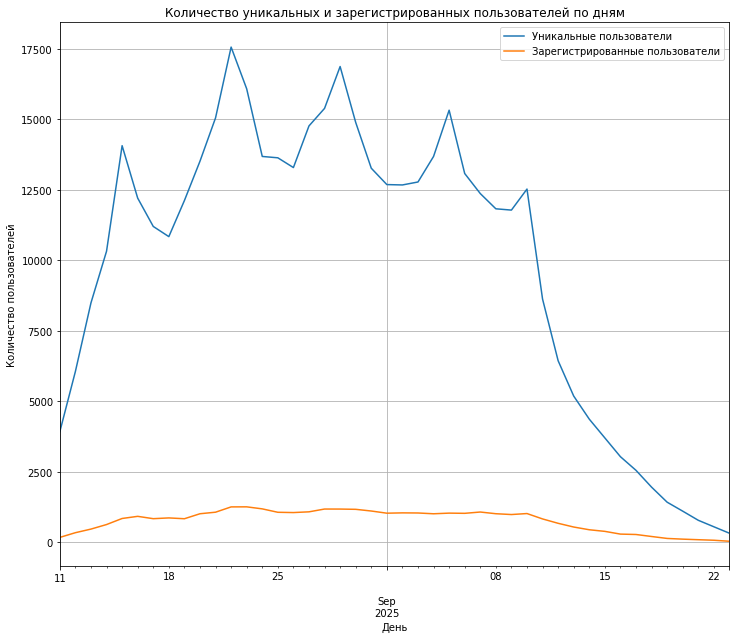

In [10]:
# Задаем размер графика
plt.figure(figsize=(12, 10))

# Строим график
unique_users_per_day.plot(kind='line', label='Уникальные пользователи')
registered_users.plot(kind='line', label='Зарегистрированные пользователи')

# Настраиваем график
plt.title('Количество уникальных и зарегистрированных пользователей по дням')
plt.xlabel('День')
plt.ylabel('Количество пользователей')
plt.legend(loc='upper right')
plt.grid()

# Выводим график
plt.show()

По графику видно, что начиная с 11 сентября идет резкий спад как общего числа пользователей, так и зарегистрированных. С 17 числа пользователи совсем перестали регистрироваться. Возможных причин такого спада несколько:

* Данные могут быть не полными, например если произошел сбой при их загрузке.
* Возможно, в период с 11 августа по 11 сентября проводилась маркетинговая кампания, которая и способствовала увеличению активных и зарегистрированных пользователей.
* Обновления или сбой в работе приложения, из-за чего пользователям стало не удобно им пользоваться.

Теперь, построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

In [11]:
# Рассчитаем долю зарегистрированных пользователей от общего числа по дням
registered_users_share = registered_users_per_day / unique_users_per_day

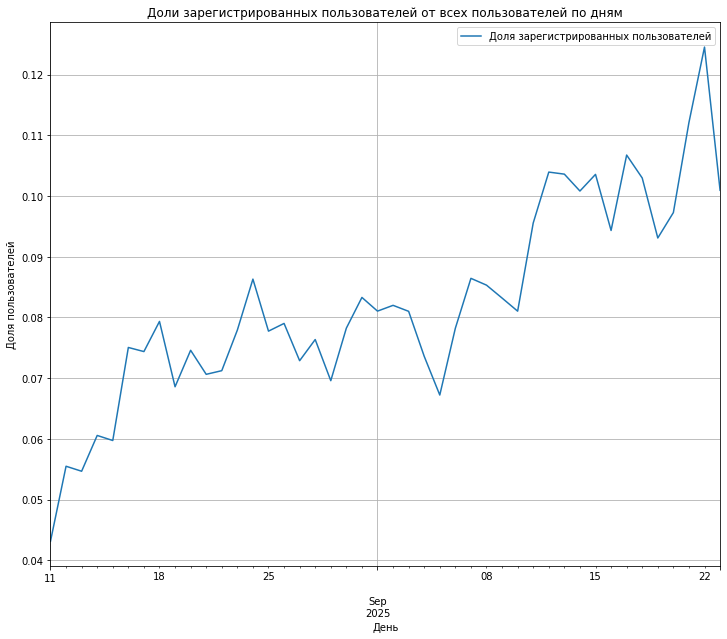

In [12]:
# Построим график доли зарегистрированных пользователей
# Задаем размер графика
plt.figure(figsize=(12, 10))

# Строим линейный график
registered_users_share.plot(kind='line', label='Доля зарегистрированных пользователей')

# Настраиваем график
plt.title('Доли зарегистрированных пользователей от всех пользователей по дням')
plt.xlabel('День')
plt.ylabel('Доля пользователей')
plt.legend(loc='upper right')
plt.grid()

# Выводим график
plt.show()

Однако, не смотря на то, что отдельное число активных и зарегистрированных пользователей падает, доля зарегистрировавшихся пользователей растет. Это указывает на то, что хоть и пользователей стало меньше, зарегистрировавшихся среди них больше, чем было раньше.

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

Нам необходимо проанализировать число просмотренных страниц во время первых сессий пользователей. Найдем количество первых сессий для каждого значения количества просмотренных страниц.

In [13]:
# Отфильтруем данные и отберем только первые сессии пользователей
first_sessions_1 = session_history[session_history['session_number'] == 1]

In [14]:
# Сгруппируем данные по количеству просмотренных страниц и посчитаем количество первых сессий для каждого числа
grouped_page_counters = first_sessions_1.groupby('page_counter')['session_id'].count()

# Выведем результат
grouped_page_counters

page_counter
1     8978
2    32494
3    50939
4    32739
5     8075
6      777
7       37
Name: session_id, dtype: int64

Теперь, построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

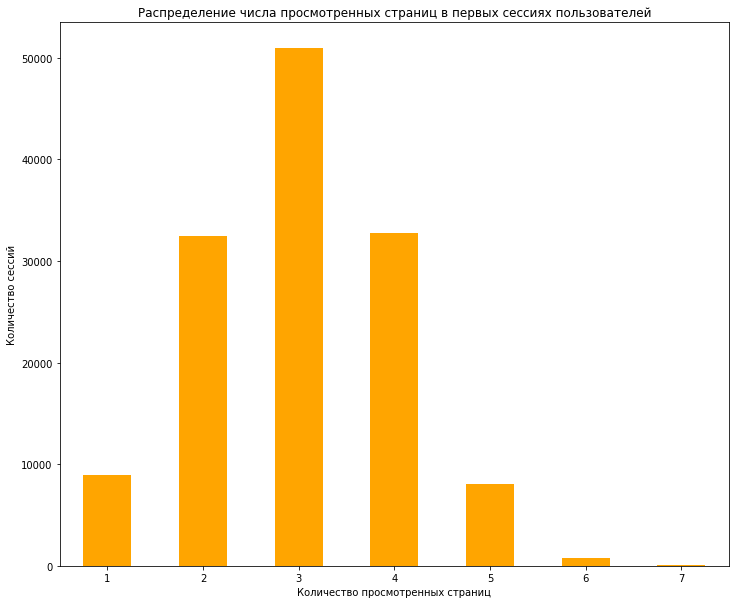

In [15]:
# Задаем размер графика
plt.figure(figsize=(12, 10))

# Строим столбчатую диаграмму
grouped_page_counters.plot(kind='bar',color='orange')

# Настраиваем график
plt.title('Распределение числа просмотренных страниц в первых сессиях пользователей')
plt.xlabel('Количество просмотренных страниц')
plt.ylabel('Количество сессий')
plt.xticks(rotation=0)

# Выводим график
plt.show()

Согласно графику, чаще всего во время своих первых сессий пользователи просматривают 2-4 страницы, реже всего - 6-7.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

In [16]:
# Создадим дополнительный стобец good_session
session_history['good_session'] = (session_history['page_counter'] >=4).astype('int')

In [17]:
# Отфильтруем данные и отберем только первые сессии пользователей
first_sessions_2 = session_history[session_history['session_number'] == 1]

In [18]:
# Посчитаем среднюю долю успешных сессий по дням 
good_sessions_share_per_day = (first_sessions_2.groupby('session_date')['good_session'].mean())

# Выводим результат
good_sessions_share_per_day

session_date
2025-08-11    0.312835
2025-08-12    0.298344
2025-08-13    0.306861
2025-08-14    0.319098
2025-08-15    0.311114
2025-08-16    0.308424
2025-08-17    0.319342
2025-08-18    0.313089
2025-08-19    0.314370
2025-08-20    0.309108
2025-08-21    0.309002
2025-08-22    0.309504
2025-08-23    0.302132
2025-08-24    0.316413
2025-08-25    0.306655
2025-08-26    0.318169
2025-08-27    0.314706
2025-08-28    0.314280
2025-08-29    0.313664
2025-08-30    0.310680
2025-08-31    0.305928
2025-09-01    0.331788
2025-09-02    0.315123
2025-09-03    0.310181
2025-09-04    0.309962
2025-09-05    0.299613
2025-09-06    0.315618
2025-09-07    0.310791
2025-09-08    0.301741
2025-09-09    0.297384
2025-09-10    0.310047
Name: good_session, dtype: float64

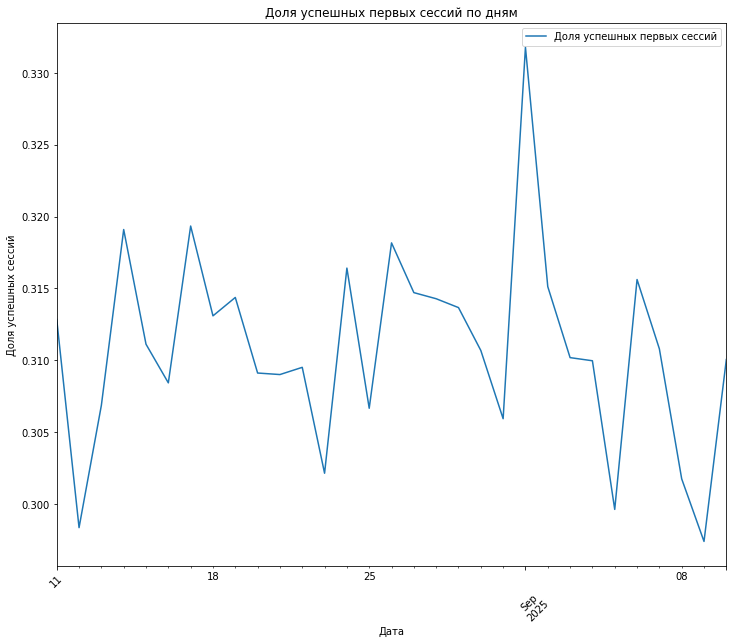

In [19]:
# Задаем размер графика
plt.figure(figsize=(12, 10))

# Строим линейный график
good_sessions_share_per_day.plot(kind='line', label='Доля успешных первых сессий')

plt.title('Доля успешных первых сессий по дням')
plt.xlabel('Дата')
plt.ylabel('Доля успешных сессий')

plt.legend()
plt.xticks(rotation=45)

plt.show()

Доля успешных первых сессий по дням, в период с 11 августа по 11 сентябряЮ стабильна и колеблется в диапазоне от 29% до 33%.

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
Рассчитаем размеры выборки.

Для этого установим в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%.

При расчёте размера выборки будем использовать метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

In [20]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлим в большую сторону.

In [21]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = unique_users_per_day.mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil((2 * sample_size) / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

Считаем и сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

In [22]:
# Выгружаем данные из файла и сохраним в датафрейм 'sessions_test_part'
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

Теперь, рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

In [23]:
# Сгруппируем данные по тестовым группам и рассчитаем количество уникальных пользователей для каждой из них
first_day_unique_users = sessions_test_part.groupby('test_group')['user_id'].nunique()

Судя по полученным данным, в группе B на 10 пользователей меньше, чем в группе A. Рассчитаем процентную разницу в количестве пользователей в группах A и B. Для расчёта процентной разницы воспользуемся формулой:

$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [24]:
# Сохраним в переменную group_a количество уникальных пользователей для группы А
group_a = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique()
# Сохраним в переменную group_b количество уникальных пользователей для группы В
group_b = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique()

In [25]:
# Считаем процентную разницу по формуле
P = 100 * abs(group_a - group_b) / group_a

# Выведем полученный результат
print(f"Процентная разница между группами: {P:.2f}%")

Процентная разница между группами: 0.74%


Построим столбчатую диаграмму, на которой будет видно различие двух групп.

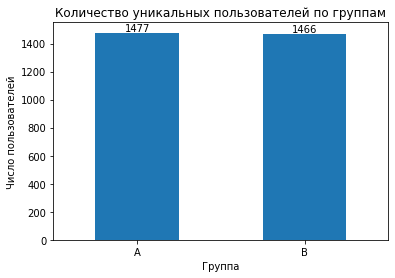

In [26]:
# Строим столбчатую диаграмму
first_day_unique_users.plot(kind='bar')

# Добавим заголовок и подписи осей
plt.title('Количество уникальных пользователей по группам')
plt.xlabel('Группа')
plt.ylabel('Число пользователей')

# Уберем поворот надписей по оси Х
plt.xticks(rotation=0)

# Добавим подписи значений
for i, v in enumerate(first_day_unique_users):
    plt.text(i, v, str(v), ha='center', va='bottom')

# Покажем диаграмму
plt.show()

Рассхождение между группами небольшое - всего 10 пользователей, поэтому этим можно пренебречь.

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

Проверим, есть ли пользователи, которые встречаются одновременно в группах A и B, и посчитаем их количество.

In [27]:
# Выбираем пользователей для групп А и В
group_a_users = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
group_b_users = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']

# Ищем, есть ли пересечения
intersection = list(set(group_a_users) & set(group_b_users))

# Выводим результат
intersection

[]

Отлично! Группы независимы, то есть пользователей, которые попали в обе группы нет.

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.


In [28]:
# Найдем доли каждого типа устройства для пользователей из группы А
device_share_a = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('device')['user_id'].nunique() / sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique()


# Найдем доли каждого типа устройства для пользователей из группы B
device_share_b = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('device')['user_id'].nunique() / sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique()

print(f"Доля каждого типа устройства для пользователей из группы A")
display(device_share_a)
print(f"Доля каждого типа устройства для пользователей из группы B")
display(device_share_b)

Доля каждого типа устройства для пользователей из группы A


device
Android    0.444144
Mac        0.105619
PC         0.249831
iPhone     0.200406
Name: user_id, dtype: float64

Доля каждого типа устройства для пользователей из группы B


device
Android    0.455662
Mac        0.100955
PC         0.259891
iPhone     0.183492
Name: user_id, dtype: float64

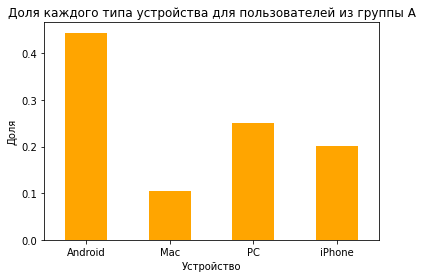

In [29]:
# Строим столбчатую диаграмму для группы А
device_share_a.plot(kind='bar',color='orange')

# Добавим заголовок и подписи осей
plt.title('Доля каждого типа устройства для пользователей из группы A')
plt.xlabel('Устройство')
plt.ylabel('Доля')

# Уберем поворот надписей по оси Х
plt.xticks(rotation=0)

# Покажем диаграмму
plt.show()

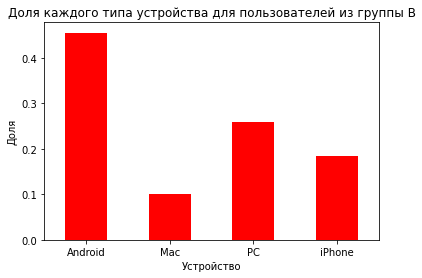

In [30]:
# Строим столбчатую диаграмму для группы B
device_share_b.plot(kind='bar',color='red')

# Добавим заголовок и подписи осей
plt.title('Доля каждого типа устройства для пользователей из группы B')
plt.xlabel('Устройство')
plt.ylabel('Доля')

# Уберем поворот надписей по оси Х
plt.xticks(rotation=0)

# Покажем диаграмму
plt.show()

По полученным диаграммам, можно сделать вывод, что распределение пользователей по типам устройств в группах A и B в целом совпадает. Доли устройств отличаются незначительно: в группе B немного выше доля Android и PC, а в группе A — iPhone и Mac. Эти различия невелики и, скорее всего, не оказывают существенного влияния на результаты A/B-теста, что говорит о корректном разделении пользователей на группы.

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

In [31]:
# Найдем доли каждого региона для пользователей из группы А
region_share_a = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('region')['user_id'].nunique() / sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique()


# Найдем доли каждого региона для пользователей из группы B
region_share_b = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('region')['user_id'].nunique() / sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique()

print(f"Доля каждого региона для пользователей из группы A")
display(region_share_a)
print(f"Доля каждого региона для пользователей из группы B")
display(region_share_b)

Доля каждого региона для пользователей из группы A


region
CIS     0.436019
EU      0.151659
MENA    0.412322
Name: user_id, dtype: float64

Доля каждого региона для пользователей из группы B


region
CIS     0.439973
EU      0.148022
MENA    0.412005
Name: user_id, dtype: float64

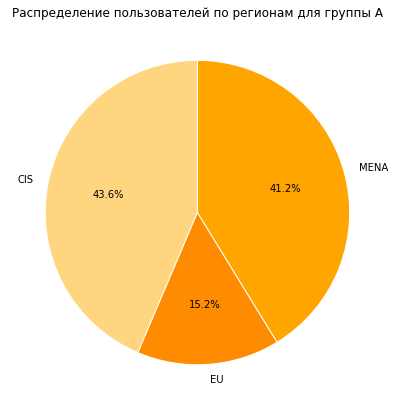

In [32]:
# Задаем размеры диаграммы
plt.figure(figsize=(7, 7))

# Строим круговую диаграмму для группы А
plt.pie(
    region_share_a,
    labels=region_share_a.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
    colors=['#FFD580', '#FF8C00', '#FFA500'])

# Добавляем заголовок
plt.title('Распределение пользователей по регионам для группы А')

# Покажем диаграмму
plt.show()

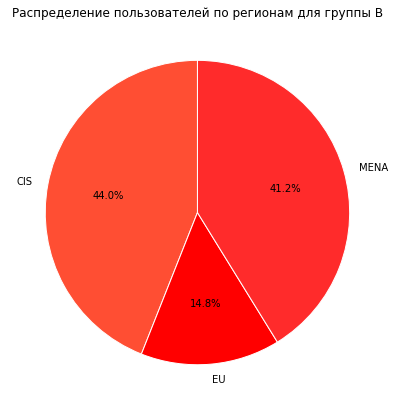

In [33]:
# Задаем размеры диаграммы
plt.figure(figsize=(7, 7))

# Строим круговую диаграмму для группы А
plt.pie(
    region_share_b,
    labels=region_share_b.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
    colors=['#FF4E33', '#FF0000', '#FF2B2B'])

# Добавляем заголовок
plt.title('Распределение пользователей по регионам для группы В')

# Покажем диаграмму
plt.show()

Распределение пользователей по регионам в группах A и B также практически совпадает. Доли регионов отличаются незначительно: в группе А чуть больше доля региона EU, а в группе B — CIS. Различия небольшие, что также говорит о корректном разделении пользователей на группы.

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста были получены следующие выводы:

- Было обнаружено небольшое различие в количестве пользователей в двух группах: в группе А было на 10 пользователей больше, чем в групее В. Разница незначительна, поэтому количество пользователей в группах не меняли.

- Выборки независимы. Пересечение пользователей из тестовой и контрольной групп не нашлось.

- Распределение пользователей тестовой и контрольной групп по категориальным переменным (устройствам и регионам) равномерно. 

A/B-тест проходит корректно, какие-либо нарушения не наблюдаются.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

Считаем и сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

In [34]:
# Выгружаем данные из файла
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [35]:
# Создаем новый столбец
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

**Нулевая гипотеза (H0):**

Доля успешных первых сессий в группе с новым алгоритмом не отличается от доли успешных первых сессий в группе со старым алгоритмом.

**Альтернативная гипотеза (H1):**

Доля успешных первых сессий в группе с новым алгоритмом выше, чем в группе со старым алгоритмом.

**Ключевая метрика:** доля успешных первых сессий.

**Прокси-метрики:**
    * количество повторных сессий;
    * доля зарегистрировавшихся пользователей.

**Барьерная метрика:** доля сессий без просмотров страниц.

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используя созданный ранее столбец `good_session`, рассчитаем долю успешных первых сессий для выборок A и B, а также разницу в этом показателе.

In [36]:
# Отфильтруем данные и оставим только первые сессии
first_sessions_test = sessions_test[sessions_test['session_number'] == 1]

In [37]:
# Считаем долю успешных первых сессий для группы А
good_first_sessions_a = round((first_sessions_test[first_sessions_test['test_group'] == 'A']['good_session'].mean()),3)

# Считаем долю успешных первых сессий для группы B
good_first_sessions_b = round((first_sessions_test[first_sessions_test['test_group'] == 'B']['good_session'].mean()),3)

# Выводим результат
print(f"Доля успешных первых сессий в группе А равна {good_first_sessions_a}")
print(f"Доля успешных первых сессий в группе B равна {good_first_sessions_b}")
print(f"Доля успешных первых сессий в группе B больше группы A на {round(100 * (good_first_sessions_b - good_first_sessions_a) / good_first_sessions_a, 2)}%")

Доля успешных первых сессий в группе А равна 0.316
Доля успешных первых сессий в группе B равна 0.315
Доля успешных первых сессий в группе B больше группы A на -0.32%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы получили, что количество успешных сессий в тестовой выборке примерно на 0.32% ниже, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [38]:
# Проводим Z-тест пропорций
from statsmodels.stats.proportion import proportions_ztest

# Считаем размеры выборок и количество успехо в каждой из них
n_a, n_b = [first_sessions_test[first_sessions_test['test_group']=='A']['good_session'].count(),first_sessions_test[first_sessions_test['test_group']=='B']['good_session'].count()] 
m_a, m_b = [first_sessions_test[first_sessions_test['test_group']=='A']['good_session'].sum(),first_sessions_test[first_sessions_test['test_group']=='B']['good_session'].sum()] 

# Устанавливаем уровень значимости
alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller' # так как H_1: p_a < p_b
)

p_value_ztest

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нет оснований отвергнуть нулевую гипотезу.')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print(f'Нулевая гипотеза отвергается.')

pvalue=0.5783523649187868 > 0.05
Нет оснований отвергнуть нулевую гипотезу.


В тестовой выборке доля успешных первых сессий в группе B оказалась немного ниже, чем в группе A. Результаты Z-теста показывают, что различие не является статистически значимым (p-value > 0.05), поэтому нет оснований отвергнуть нулевую гипотезу. Это означает, что на текущих данных нет оснований утверждать, что новый алгоритм улучшает долю успешных первых сессий.

#### 4.5. Вывод по результатам A/B-эксперимента

В рамках A/B-теста был проведён эксперимент по сравнению старого и нового алгоритмов рекомендаций. В тесте приняли участие пользователи, разделённые на две группы (A и B). Общая длительность эксперимента составила 21 день, среднее количество пользователей в день - 9907, суммарный объём выборки - 82080 пользователей.

В качестве ключевой метрики рассматривалась доля успешных первых сессий. По результатам анализа было установлено, что в группе B (новый алгоритм) значение метрики составило 0.316, тогда как в группе A (старый алгоритм) - 0.315. Таким образом, изменение метрики составило -0.32%.

Для оценки статистической значимости различий был проведён Z-тест для сравнения долей. Полученное значение p-value равно 0.5783523649187868. Поскольку p-value больше уровня значимости 0.05, нет оснований отвергнуть нулевую гипотезу.

Следовательно, на текущих данных не обнаружено статистически значимого улучшения ключевой метрики при использовании нового алгоритма рекомендаций.

На основании полученных результатов не рекомендуется внедрять новый алгоритм для всех пользователей. Для принятия окончательного решения можно рассмотреть возможность проведения более длительного теста или увеличения объёма выборки.